In [3]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

data = sns.load_dataset("titanic")
data.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
# Check shape of dataset (rows, columns)
print("Shape:", data.shape)
# Statistical summary of numerical data
data.describe()

Shape: (891, 15)


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
# # Count unique values in each column
print('\nCategorical columns summary:')
print('Unique values per column:')
print(data.nunique())


Categorical columns summary:
Unique values per column:
survived         2
pclass           3
sex              2
age             88
sibsp            7
parch            7
fare           248
embarked         3
class            3
who              3
adult_male       2
deck             7
embark_town      3
alive            2
alone            2
dtype: int64


In [6]:
data.isnull().sum()

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

In [13]:
# Fill missing Age with mean
data['age'] = data['age'].fillna(data['age'].mean())
# Fill missing Cabin with most frequent value
data['deck'] = data['deck'].fillna(data['deck'].mode()[0])
# Fill missing Embarked with most frequent value
data['embarked'] = data['embarked'].fillna(data['embarked'].mode()[0])
data['embark_town'] = data['embark_town'].fillna(data['embark_town'].mode()[0])
# Check again
data.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
Age            0
dtype: int64

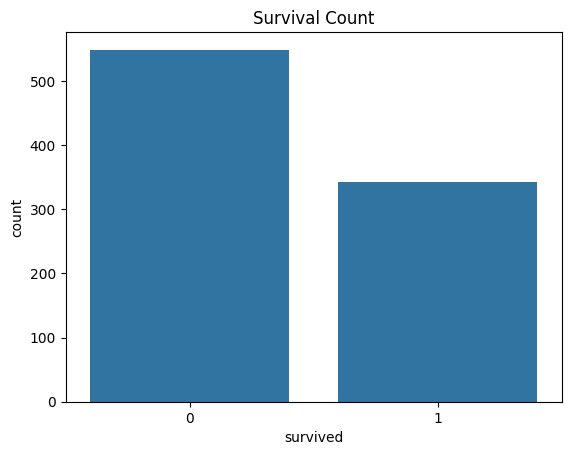

In [16]:
# Count of survived vs not survived
# showing how many passengers survived
sns.countplot(x='survived', data=data)
plt.title('Survival Count')
plt.show()

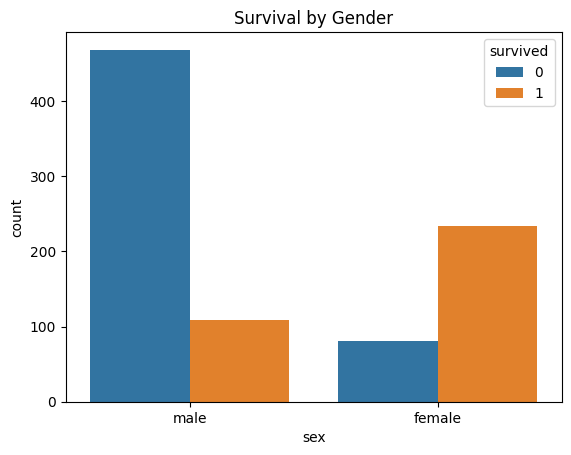

In [17]:
# Survival based on gender
sns.countplot(x='sex', hue='survived', data=data)
plt.title('Survival by Gender')
plt.show()
# It shows that females had a higher survival rate compared to males

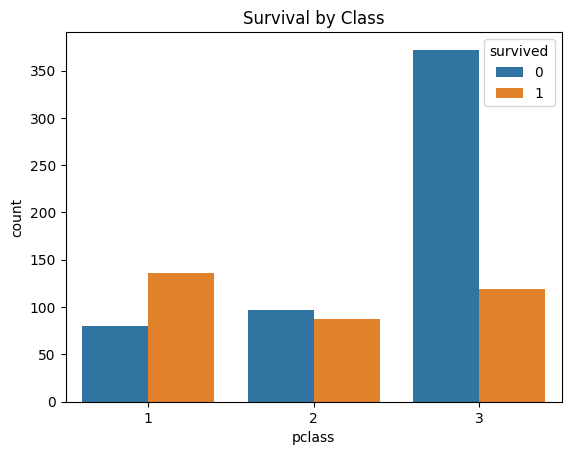

In [20]:
# Survival based on passenger class
sns.countplot(x='pclass', hue='survived', data=data)
plt.title('Survival by Class')
plt.show()
# 1st class → more survival

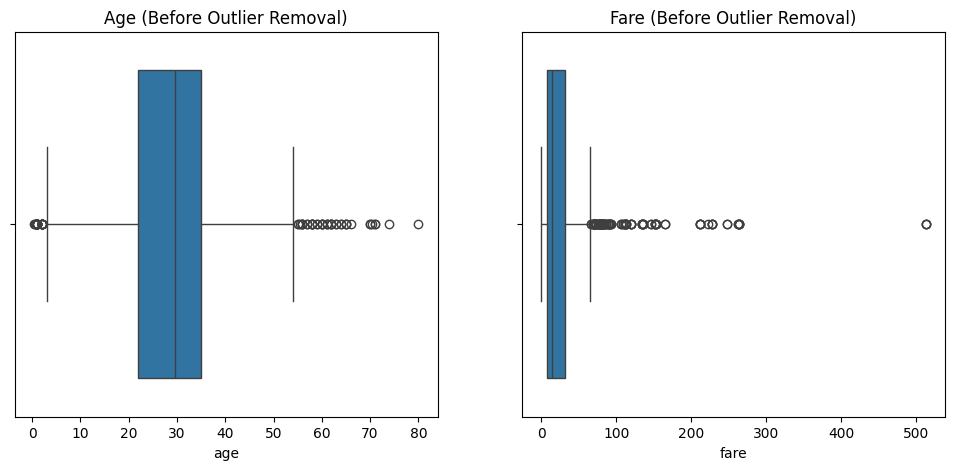

In [22]:
# Boxplots BEFORE removing outliers
plt.figure(figsize=(12,5))
# Age before
plt.subplot(1,2,1)
sns.boxplot(x=data['age'])
plt.title('Age (Before Outlier Removal)')
## This boxplot show the age distribution of passengers and shows median, spread, and outliers.
# Fare before
plt.subplot(1,2,2)
sns.boxplot(x=data['fare'])
plt.title('Fare (Before Outlier Removal)')
# This boxplot shows that most passengers paid low fares, while a few passengers paid very high fares (outliers).
plt.show()

In [27]:
# Quartiles and IQR
Q1_age = data['age'].quantile(0.25)
Q3_age = data['age'].quantile(0.75)
IQR_age = Q3_age - Q1_age
Q1_fare = data['fare'].quantile(0.25)
Q3_fare = data['fare'].quantile(0.75)
IQR_fare = Q3_fare - Q1_fare
print("Age IQR:", IQR_age)
print("Fare IQR:", IQR_fare)

# Remove outliers using 1.5 * IQR
lower_age = Q1_age - 1.5 * IQR_age
upper_age = Q3_age + 1.5 * IQR_age
lower_fare = Q1_fare - 1.5 * IQR_fare
upper_fare = Q3_fare + 1.5 * IQR_fare
data_clean = data[
    (data['age'] >= lower_age) & (data['age'] <= upper_age) &
    (data['fare'] >= lower_fare) & (data['fare'] <= upper_fare)
]
print("Shape after removing outliers:", data_clean.shape)

Age IQR: 13.0
Fare IQR: 23.0896
Shape after removing outliers: (721, 16)


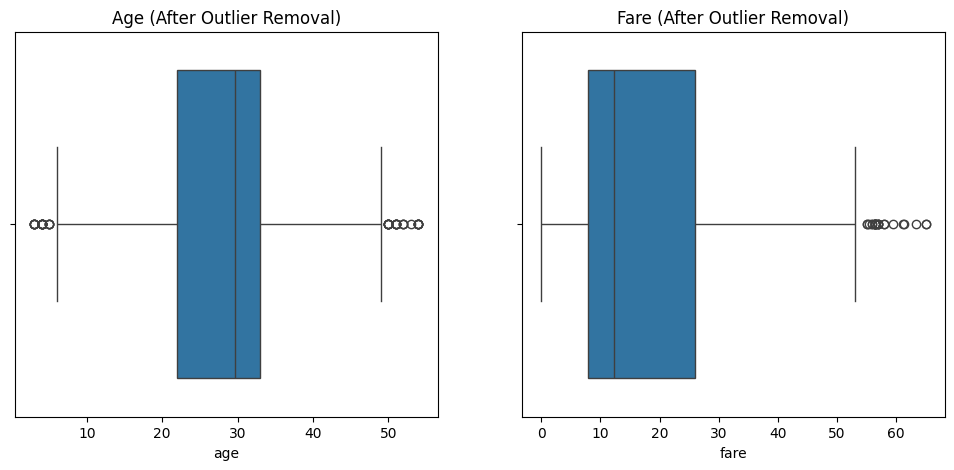

In [29]:
# Boxplots AFTER removing outliers
plt.figure(figsize=(12,5))
# Age after
plt.subplot(1,2,1)
sns.boxplot(x=data_clean['age'])
plt.title('Age (After Outlier Removal)')
# Fare after
plt.subplot(1,2,2)
sns.boxplot(x=data_clean['fare'])
plt.title('Fare (After Outlier Removal)')
plt.show()

TASK 1: Finding patterns in Titanic data


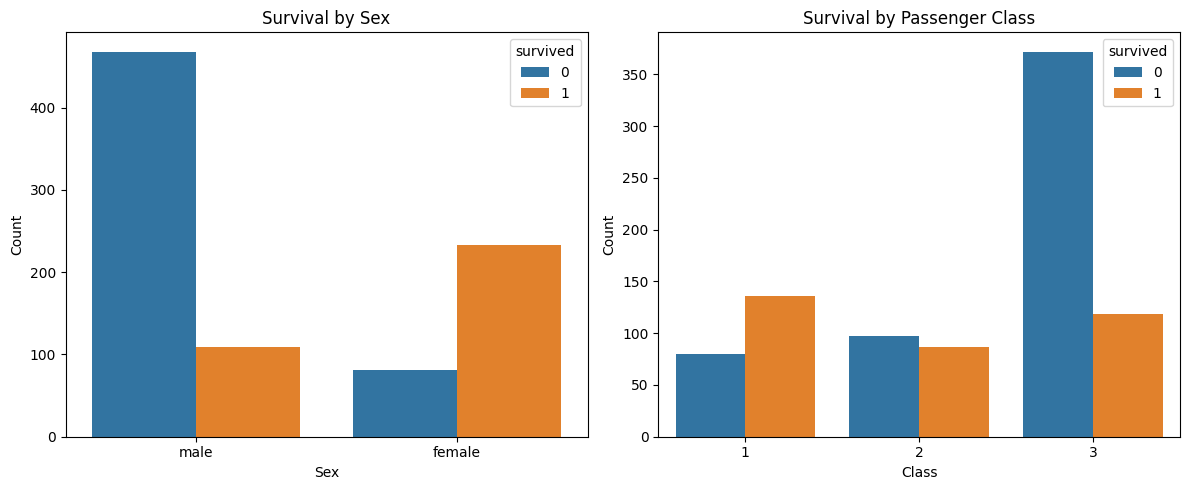


Survival Rate by Sex:
        sum  count      mean
sex                         
female  233    314  0.742038
male    109    577  0.188908

Survival Rate by Class:
        sum  count      mean
pclass                      
1       136    216  0.629630
2        87    184  0.472826
3       119    491  0.242363


In [32]:

# TASK 1: Finding patterns in Titanic data
print('TASK 1: Finding patterns in Titanic data')
plt.figure(figsize=(12, 5))
# Survival by Sex
plt.subplot(1, 2, 1)
sns.countplot(data=data, x='sex', hue='survived')
plt.title('Survival by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')
# Females survived more than males

# Survival by Class
plt.subplot(1, 2, 2)
sns.countplot(data=data, x='pclass', hue='survived')
plt.title('Survival by Passenger Class')
plt.xlabel('Class')
plt.ylabel('Count')
# 1st class passengers survived more
plt.tight_layout()
plt.show()
# Survival rate by Sex
print('\nSurvival Rate by Sex:')
print(data.groupby('sex')['survived'].agg(['sum', 'count', 'mean']))
# Survival rate by Class
print('\nSurvival Rate by Class:')
print(data.groupby('pclass')['survived'].agg(['sum', 'count',
'mean']))

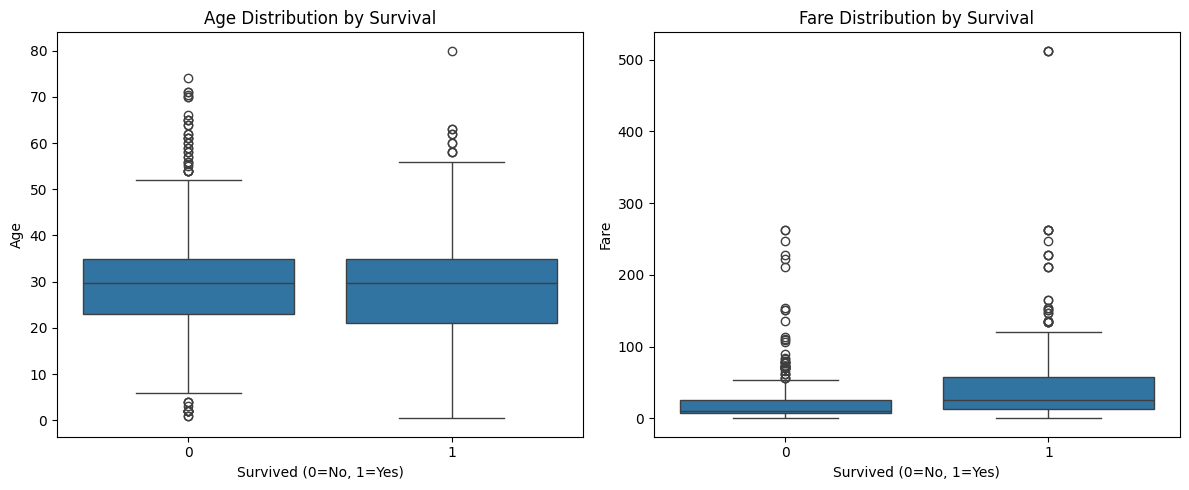

In [34]:
# Age vs Survival and Fare vs Survival
plt.figure(figsize=(12, 5))
# Age vs Survival
plt.subplot(1, 2, 1)
sns.boxplot(data=data, x='survived', y='age')
plt.title('Age Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Age')
# Shows age distribution for survived vs not survived
# Fare vs Survival
plt.subplot(1, 2, 2)
sns.boxplot(data=data, x='survived', y='fare')
plt.title('Fare Distribution by Survival')
plt.xlabel('Survived (0=No, 1=Yes)')
plt.ylabel('Fare')
# Shows that passengers who paid higher fare survived more
plt.tight_layout()
plt.show()

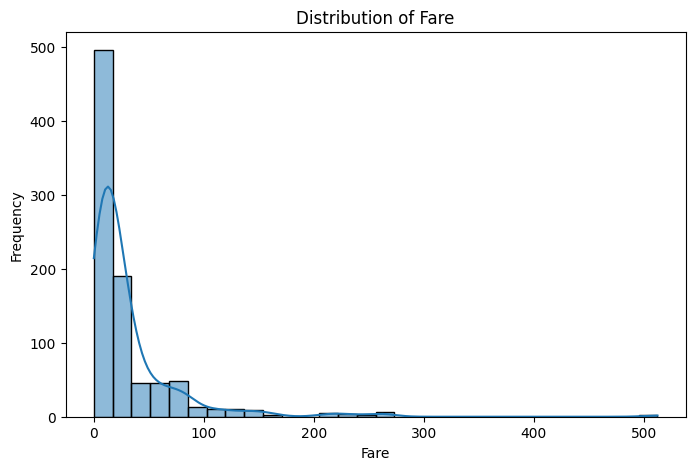

In [35]:
# Histogram to show distribution of ticket fare
plt.figure(figsize=(8,5))
sns.histplot(data['fare'], bins=30, kde=True)
plt.title('Distribution of Fare')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()
# Most passengers paid low fares, few paid very high fares

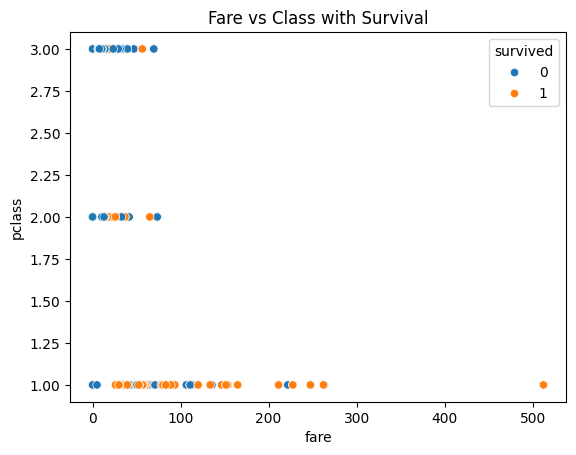

In [37]:
# Relationship between fare and class with survival
sns.scatterplot(x='fare', y='pclass', hue='survived', data=data)
plt.title('Fare vs Class with Survival')
plt.show()
# Higher fare and 1st class passengers survived more

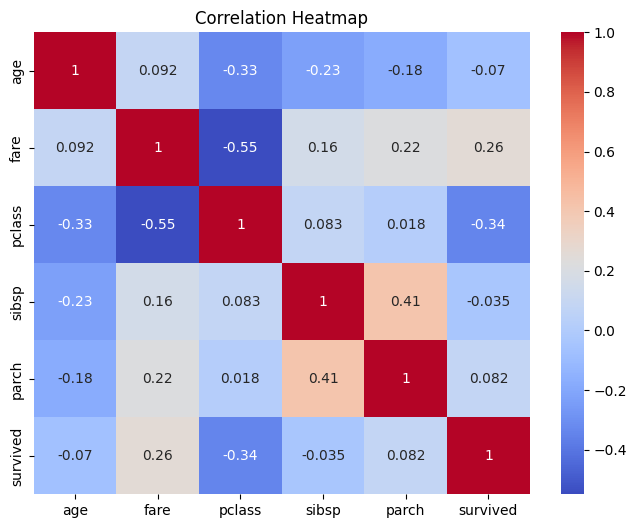

In [40]:
# Correlation Heatmap
# Select numeric columns
numeric_cols = ['age', 'fare', 'pclass', 'sibsp', 'parch', 'survived']
# Calculate correlation
corr = data[numeric_cols].corr()
# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
#Fare → positive with survival ✔️
#Pclass → negative with survival ✔️
#Age → weak relation

In [42]:
print(data['survived'].value_counts())

survived
0    549
1    342
Name: count, dtype: int64


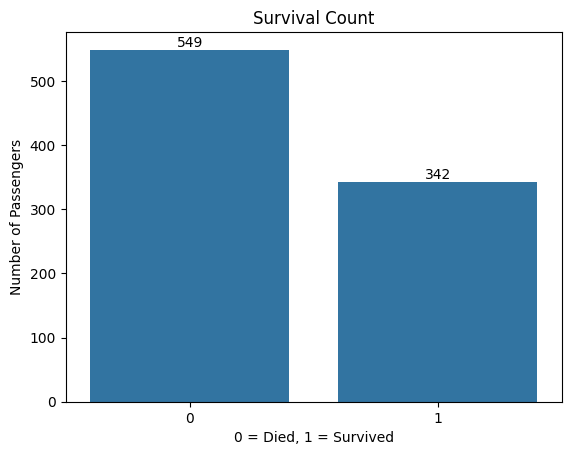

In [43]:
#Shows number and percentage of passengers who survived and died

# Survival count graph
values = data['survived'].value_counts()
ax = sns.barplot(x=values.index, y=values.values)
# Add numbers on bars
for i, v in enumerate(values.values):
    ax.text(i, v + 5, str(v), ha='center')
plt.title('Survival Count')
plt.xlabel('0 = Died, 1 = Survived')
plt.ylabel('Number of Passengers')
plt.show()

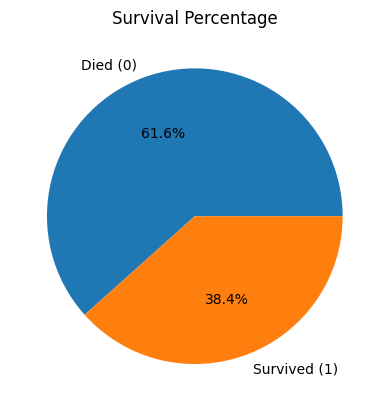

In [44]:
# Pie chart for survival
labels = ['Died (0)', 'Survived (1)']
sizes = data['survived'].value_counts()
plt.pie(sizes, labels=labels, autopct='%1.1f%%')
plt.title('Survival Percentage')
plt.show()